# 📈 S&P 500 Stock Market — Exploratory Data Analysis

**Author:** Shailendra Gadakari
**Date:** 15th March 2026  
**Tools:** Python · SQLite · Pandas · Matplotlib · Seaborn

---

## Overview
This project performs an exploratory data analysis on historical S&P 500 stock price data 
spanning 2013 to 2018. Using SQL queries via Python's SQLite connector, the analysis 
investigates price trends, market volatility, single-day extremes, and trading volume 
behaviour across 500 companies.

## Dataset
- **Source:** [Kaggle — S&P 500 Stock Data](https://www.kaggle.com/datasets/camnugent/sandp500)
- **Records:** 619,040 rows
- **Coverage:** 505 companies · 2013–2018
- **Columns:** date, open, high, low, close, volume, name

## 1. Data Loading

The dataset is loaded from a local CSV file into a SQLite database using Pandas. 
This approach allows us to query the data using SQL while remaining entirely within 
the Python and Jupyter environment — no external database server required.

In [14]:
import sqlite3
import pandas as pd

# load csv into a dataframe
df = pd.read_csv('data/all_stocks_5yr.csv')

# clean column names (lowercase, no spaces)
df.columns = df.columns.str.strip().str.lower()

# connect to sqlite database (or create it if it doesn't exist)
conn = sqlite3.connect('stock_eda.db')

# write the dataframe to a new table called 'stocks'
df.to_sql('stocks', conn, if_exists='replace', index=False)

print(f"Data Loaded Successfully! {len(df):,} rows imported.")

Data Loaded Successfully! 619,040 rows imported.


## 2. Libraries & Database Connection

We import the core libraries used throughout this analysis and establish a connection 
to the SQLite database. The connection object `conn` is passed directly to 
`pandas.read_sql()` to execute all subsequent queries.

In [15]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

conn = sqlite3.connect('stock_eda.db')
print("Connected to stock_eda.db successfully!")

Connected to stock_eda.db successfully!


## 3. Data Profiling

Before any analysis, we verify the integrity and scope of the dataset — confirming 
the total number of records, the number of distinct companies, and the full date range 
covered. This is a standard first step in any data analysis workflow to ensure the 
data has loaded correctly and completely.

In [5]:
query = """
SELECT COUNT(*) AS total_records,
COUNT(DISTINCT name) AS total_companies,
MIN(date) AS earliest_date,
MAX(date) AS latest_date
FROM stocks;
"""

pd.read_sql(query, conn)


,total_records,total_companies,earliest_date,latest_date
0,619040,505,2013-02-08,2018-02-07


## 4. Top 15 Stocks by Average Closing Price

This query calculates the mean closing price per stock across the entire five-year 
period. A higher average closing price does not necessarily indicate better performance, 
but it reveals which companies traded at the highest valuations historically. 

**What to look for:** Recognisable blue-chip names such as The Priceline Group (PCLN), Alphabet Inc. (Google's parent company) (GOOG & GOOGL) and Amazon (AMZN) tend to dominate this list due to their high nominal share prices.

#### Query Output

In [18]:
query = """
SELECT name, ROUND(AVG(close), 2) AS avg_close
FROM stocks
GROUP BY name
ORDER BY avg_close DESC
LIMIT 15;"""
df_top = pd.read_sql(query, conn)
df_top

,name,avg_close
0,PCLN,1312.87
1,GOOG,725.40
2,GOOGL,682.23
3,AZO,619.70
4,AMZN,576.88
5,CMG,493.26
6,REGN,381.83
7,MTD,356.30
8,BLK,348.63
9,BIIB,295.41


#### Visualisation

C:\Users\shail\AppData\Local\Temp\ipykernel_21896\841736429.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top, x='name', y='avg_close', palette = 'Blues_d')


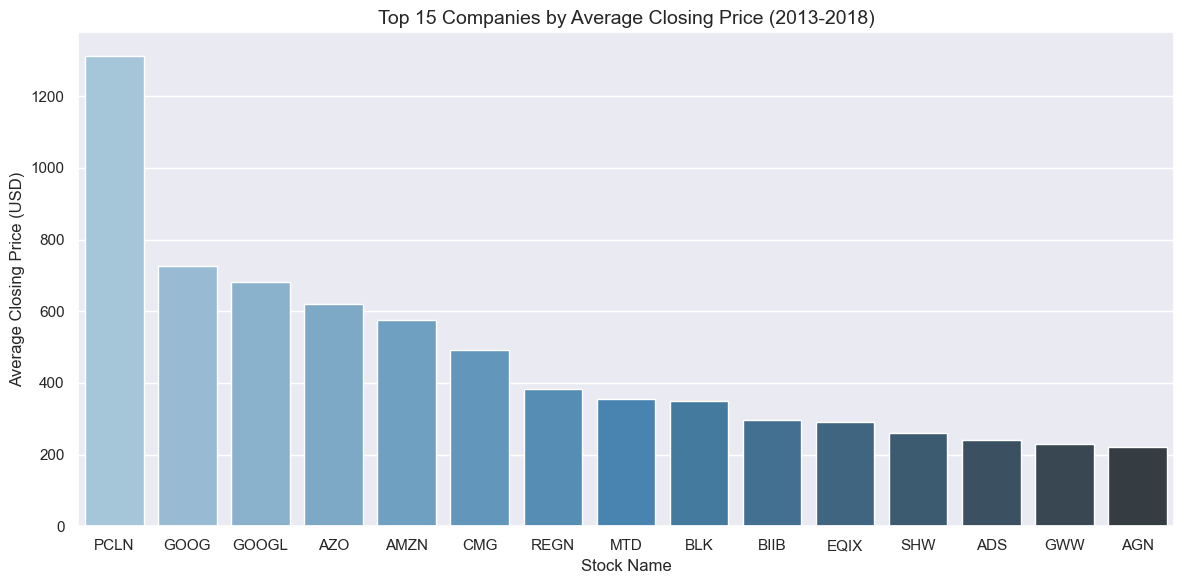

In [19]:

sns.barplot(data=df_top, x='name', y='avg_close', palette = 'Blues_d')
plt.title('Top 15 Companies by Average Closing Price (2013-2018)', fontsize=14)
plt.xlabel('Stock Name', fontsize=12)
plt.ylabel('Average Closing Price (USD)', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Market Volatility by Year

Volatility is measured here as the average daily price range (high minus low) across 
all stocks for each year. A wider range indicates more intraday price movement, 
reflecting broader market uncertainty or major macroeconomic events.

**What to look for:** Years with notable economic events — such as the market correction 
in late 2018 — are expected to show elevated volatility compared to calmer periods.

#### Query Output

In [16]:
query = """
SELECT STRFTIME('%Y', date) AS year,
ROUND(AVG(high - low), 2) AS avg_daily_range
FROM stocks
GROUP BY year
ORDER BY year;"""
df_vol = pd.read_sql(query, conn)
df_vol

,year,avg_daily_range
0,2013,1.15
1,2014,1.38
2,2015,1.67
3,2016,1.69
4,2017,1.57
5,2018,2.44


#### Visualisation

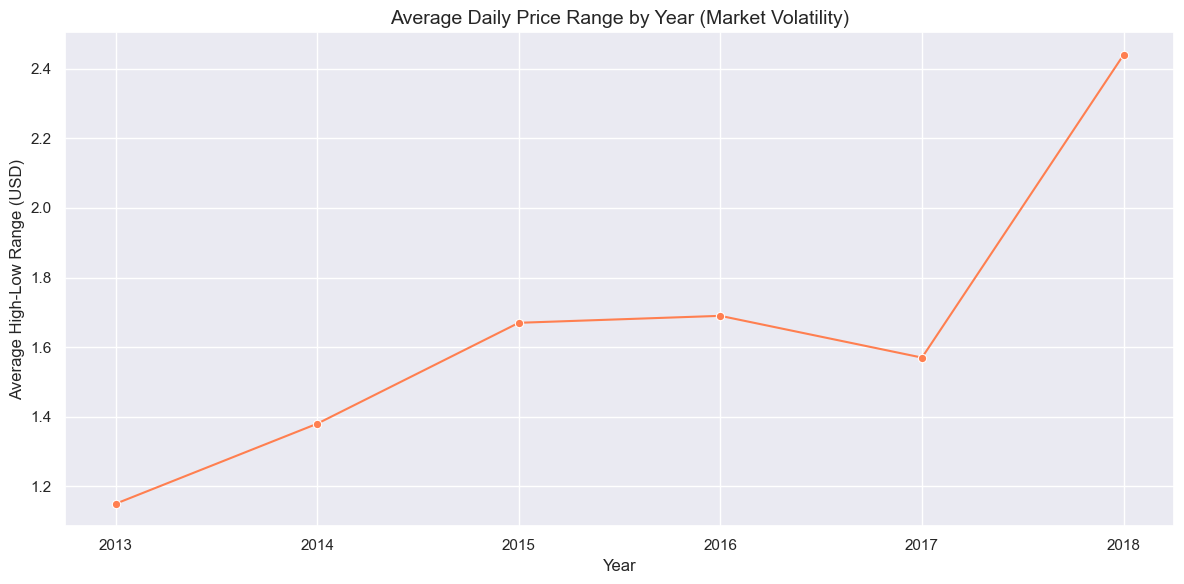

In [17]:
sns.lineplot(data=df_vol, x='year', y='avg_daily_range', marker='o', color='coral')
plt.title('Average Daily Price Range by Year (Market Volatility)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average High-Low Range (USD)', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Top 10 Single-Day Percentage Gains

This query identifies the ten largest single-day price gains across the entire dataset, 
calculated as the percentage change from the opening to closing price on a given day. 
These extreme events are often linked to earnings surprises, acquisition announcements, 
or broader market rallies.

**What to look for:** Small-cap or mid-cap stocks tend to appear here more than large-caps, 
as they are more susceptible to sharp price movements on high-impact news.

#### Query Output

In [20]:
query = """
SELECT name, date,
ROUND((close - open) / open * 100, 2) AS gain_pct
FROM stocks
WHERE open > 0
ORDER BY gain_pct DESC
LIMIT 10;"""
df_gains = pd.read_sql(query, conn)
df_gains

,name,date,gain_pct
0,CHD,2014-05-19,80.58
1,WMB,2016-01-14,36.29
2,CHK,2016-03-02,29.77
3,CHK,2016-03-03,26.71
4,AMD,2016-04-22,25.08
5,CHK,2016-04-12,25.00
6,HUM,2015-05-29,20.17
7,HOG,2016-07-01,19.47
8,RRC,2016-01-21,18.48
9,PRGO,2015-04-08,18.40


#### Visualisation

C:\Users\shail\AppData\Local\Temp\ipykernel_21896\130435152.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_gains, x='gain_pct', y='name', palette='Greens_d')


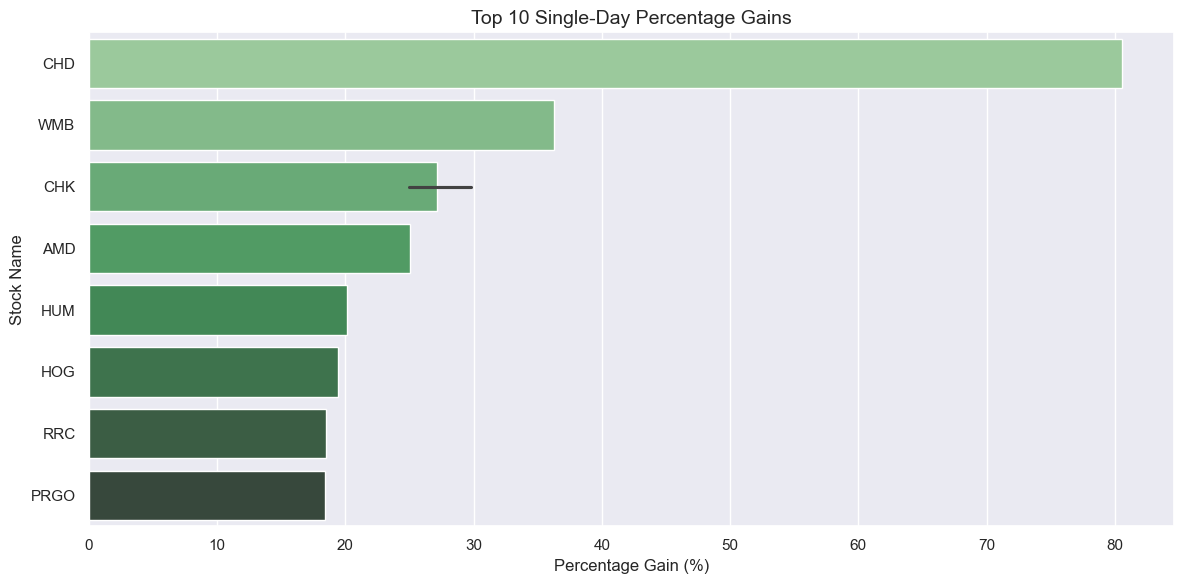

In [25]:
sns.barplot(data=df_gains, x='gain_pct', y='name', palette='Greens_d')
plt.title('Top 10 Single-Day Percentage Gains', fontsize=14)
plt.xlabel('Percentage Gain (%)', fontsize=12)
plt.ylabel('Stock Name', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Average Trading Volume — Up Days vs Down Days

This query examines whether market participants trade more heavily on days when prices 
rise or fall. Higher volume on down days can indicate panic selling, while higher volume 
on up days may reflect strong buying conviction or momentum.

**What to look for:** A meaningful difference in average volume between up and down days 
would suggest that price direction is correlated with market participation levels.

**Key Finding:** Contrary to expectations, flat days recorded the highest average 
trading volume across the dataset, pointing to heavy two-sided activity on days 
where buyers and sellers were evenly matched.

#### Query Output

In [23]:
query ="""
SELECT
CASE WHEN close > open THEN 'Up Day'
WHEN close < open THEN 'Down Day'
ELSE 'Flat'
END AS day_type,
ROUND(AVG(volume), 0) AS avg_volume
FROM stocks
GROUP BY day_type"""
df_day = pd.read_sql(query, conn)
df_day

,day_type,avg_volume
0,Down Day,4403383.0
1,Flat,5146096.0
2,Up Day,4233354.0


#### Visualisation

C:\Users\shail\AppData\Local\Temp\ipykernel_21896\1760156323.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_day, x='day_type', y='avg_volume', palette=palette)


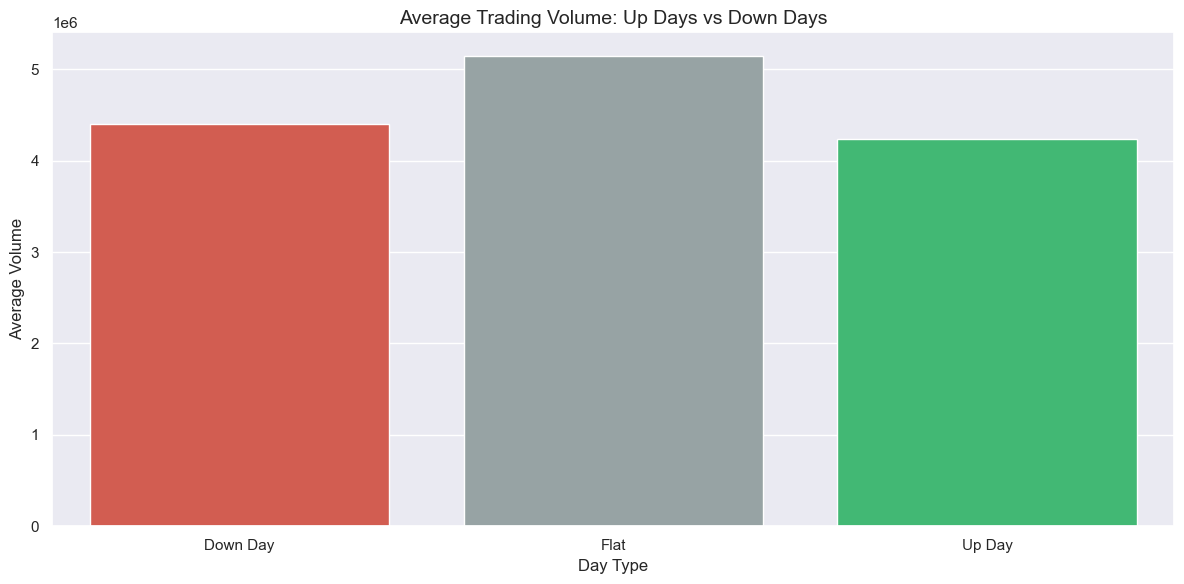

In [24]:
palette = {"Up Day": "#2ecc71", "Flat": "#95a5a6", "Down Day": "#e74c3c"}
sns.barplot(data=df_day, x='day_type', y='avg_volume', palette=palette)
plt.title('Average Trading Volume: Up Days vs Down Days', fontsize=14)
plt.xlabel('Day Type', fontsize=12)
plt.ylabel('Average Volume', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Most Consistent Stocks — Stability Ratio

Using a Common Table Expression (CTE), this query calculates a stability ratio for 
each stock — defined as its average closing price divided by its total price range 
over the five-year period. A higher ratio indicates a stock that traded at a high 
value relative to how much it fluctuated, suggesting price consistency.

**What to look for:** Defensive sector stocks — such as utilities, consumer staples, 
and healthcare — typically exhibit higher stability ratios than technology or energy stocks.

In [12]:
query = """
WITH stock_stats AS (
    SELECT
        name,
        ROUND(AVG(close), 2) AS avg_close,
        ROUND(MAX(close) - MIN(close), 2) AS price_range
    FROM stocks
    GROUP BY name
)
SELECT
    name,
    avg_close,
    price_range,
    ROUND(avg_close / NULLIF(price_range, 0), 2) AS stability_ratio
FROM stock_stats
ORDER BY stability_ratio DESC
LIMIT 15;
"""

pd.read_sql(query, conn)

,name,avg_close,price_range,stability_ratio
0,APTV,89.49,12.97,6.90
1,DWDP,71.42,12.34,5.79
2,KO,42.12,11.69,3.60
3,VZ,49.01,13.69,3.58
4,BHF,60.14,17.00,3.54
5,SO,46.64,14.42,3.23
6,PG,83.05,26.34,3.15
7,T,36.40,11.67,3.12
8,KHC,82.19,27.45,2.99
9,PPL,34.06,11.61,2.93


## 9. Closing Price Trend — APTV (2013–2018)

We isolate a single stock to visualise its price trajectory over the full five-year 
period. APTV was identified as the most consistent stock in the dataset and this 
chart confirms the stability of its price movement over time.

#### Query Output

In [27]:
query = """
SELECT date, close
FROM stocks
WHERE name = 'APTV'
ORDER BY date;
"""
df_aptv = pd.read_sql(query, conn)
df_aptv

,date,close
0,2017-12-05,88.77
1,2017-12-06,85.36
2,2017-12-07,84.38
3,2017-12-08,85.22
4,2017-12-11,85.89
5,2017-12-12,85.67
6,2017-12-13,83.56
7,2017-12-14,83.05
8,2017-12-15,84.40
9,2017-12-18,84.24


#### Visualisation

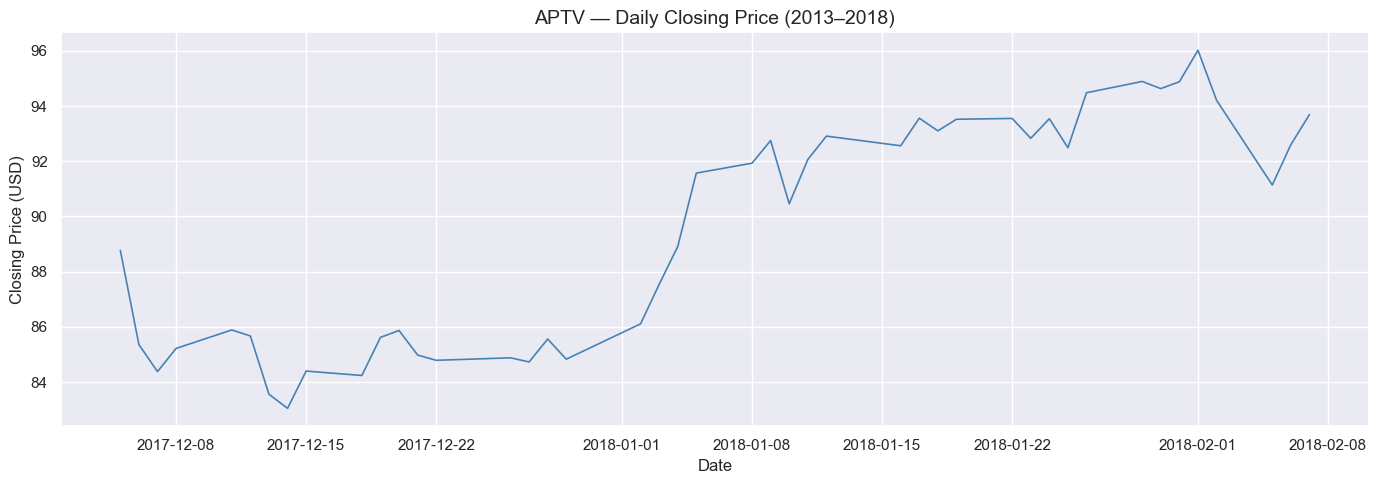

In [28]:
df_aptv['date'] = pd.to_datetime(df_aptv['date'])
plt.figure(figsize=(14, 5))
plt.plot(df_aptv['date'], df_aptv['close'], color='steelblue', linewidth=1.2)
plt.title("APTV — Daily Closing Price (2013–2018)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.tight_layout()
plt.show()

## 10. Top 15 Most Traded Stocks by Average Daily Volume

Trading volume is a measure of market liquidity and investor interest. This query 
identifies the stocks that attracted the highest average daily trading volume across 
the dataset, indicating where market participants were most active.

#### Query Output

In [30]:
query = """
SELECT name, ROUND(AVG(volume), 0) AS avg_volume
FROM stocks
GROUP BY name
ORDER BY avg_volume DESC
LIMIT 15;
"""
df_volume = pd.read_sql(query, conn)
df_volume

,name,avg_volume
0,BAC,93633800.0
1,AAPL,54047900.0
2,GE,42115683.0
3,F,34462375.0
4,FB,34359265.0
5,MSFT,33869463.0
6,AMD,32519038.0
7,MU,30248411.0
8,INTC,29326714.0
9,CSCO,28654350.0


#### Visualisation

C:\Users\shail\AppData\Local\Temp\ipykernel_21896\644076496.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_volume, x="name", y="avg_volume", palette="Purples_d")


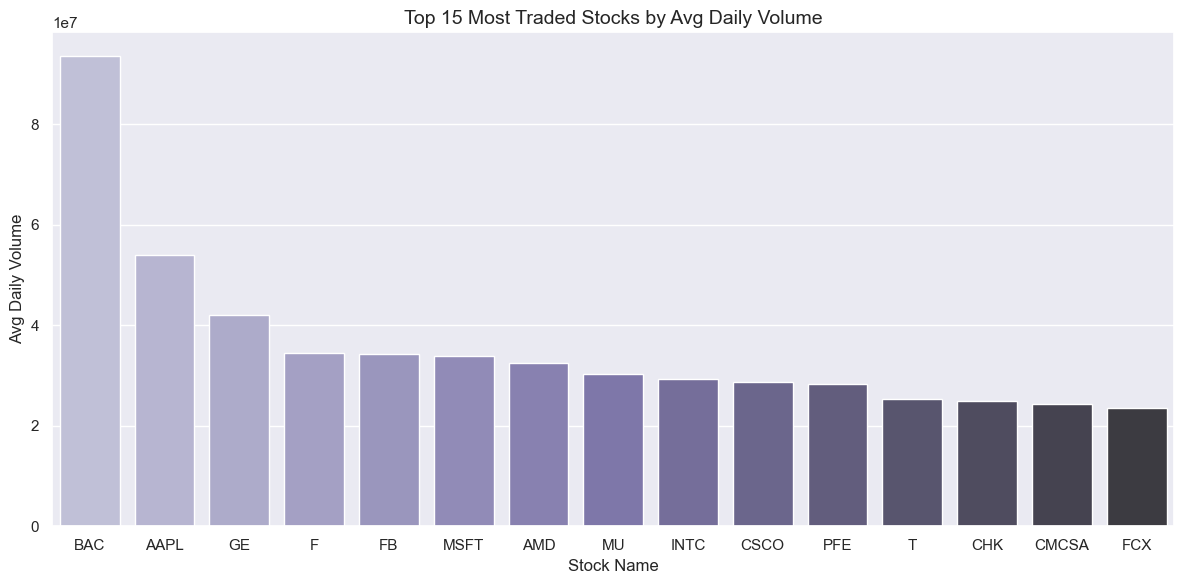

In [32]:
sns.barplot(data=df_volume, x="name", y="avg_volume", palette="Purples_d")
plt.title("Top 15 Most Traded Stocks by Avg Daily Volume", fontsize=14)
plt.xlabel("Stock Name")
plt.ylabel("Avg Daily Volume")
plt.tight_layout()
plt.show()

## 11. Top 10 Single-Day Percentage Losses

To complement the analysis of single-day gains, this query identifies the ten largest 
single-day price drops across the dataset. These events are typically associated with 
earnings disappointments, regulatory actions, or broader market selloffs.

#### Query Output

In [38]:
query = """
SELECT name, date,
    ROUND((close - open) / open * 100, 2) AS loss_pct
FROM stocks
WHERE open > 0
ORDER BY loss_pct ASC
LIMIT 10;
"""
df_losses = pd.read_sql(query, conn)
df_losses

,name,date,loss_pct
0,LNT,2016-05-19,-49.22
1,WMB,2016-02-08,-25.25
2,CHK,2016-02-08,-20.31
3,FCX,2016-01-11,-20.19
4,PWR,2015-10-16,-18.73
5,VIAB,2016-02-09,-17.93
6,NRG,2015-12-04,-17.73
7,WMB,2016-01-13,-17.42
8,CHK,2016-05-06,-16.85
9,NFLX,2013-10-22,-16.84


C:\Users\shail\AppData\Local\Temp\ipykernel_21896\1184128215.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_losses, x="loss_pct", y="name", palette="Reds_d")


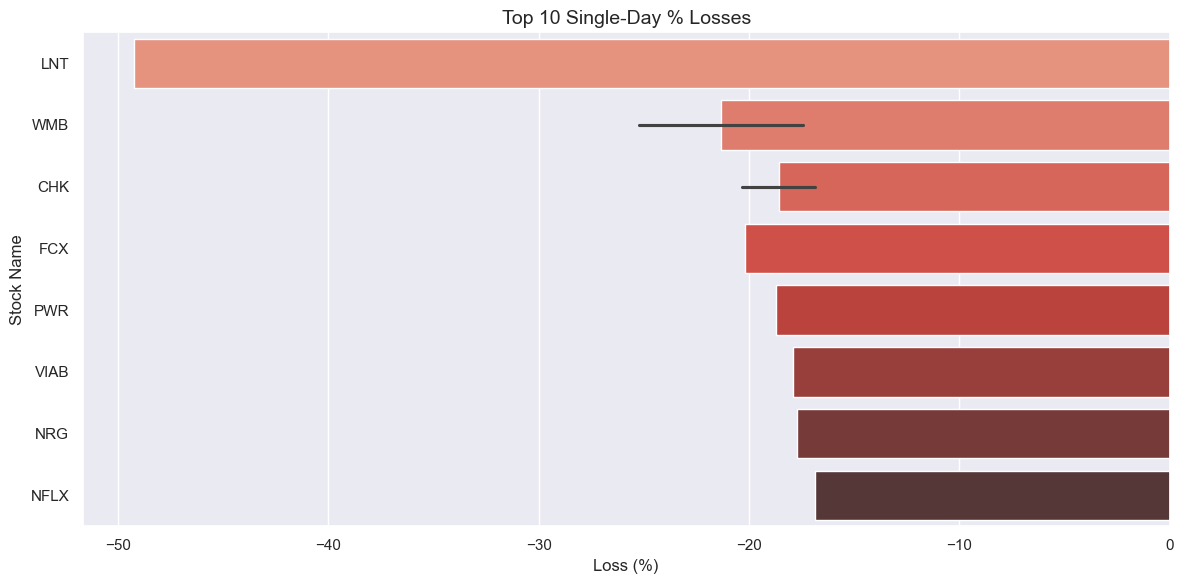

In [41]:
sns.barplot(data=df_losses, x="loss_pct", y="name", palette="Reds_d")
plt.title("Top 10 Single-Day % Losses", fontsize=14)
plt.xlabel("Loss (%)")
plt.ylabel("Stock Name")
plt.tight_layout()
plt.show()

## 12. Summary & Conclusions

| # | Question | Finding |
|---|----------|---------|
| 1 | Highest avg closing price | PCLN (Priceline) recorded the highest avg closing price at $1,312.87, reflecting its position as one of the highest nominally valued stocks in the S&P 500 over 2013–2018 |
| 2 | Most volatile year | 2018 was the most volatile year with an avg daily price range of $2.44, likely driven by the Q4 2018 market correction triggered by interest rate hikes and trade war fears |
| 3 | Biggest single-day gain | CHD (Church & Dwight Co.) recorded the largest single-day gain at 80.58%, a highly anomalous move likely tied to a specific corporate event or data irregularity worth investigating |
| 4 | Volume trend | Flat days recorded the highest avg trading volume (5,146,096), ahead of down days (4,403,383) and up days (4,233,354), suggesting peak activity occurs during periods of market indecision where buyers and sellers are evenly matched |
| 5 | Most consistent stock | APTV (Aptiv PLC) had the highest stability ratio of 6.90, with an avg closing price of $89.49 across a price range of only $12.97, indicating remarkably steady valuation over the five-year period |
| 6 | APTV price trend | APTV traded in a tight $83–$89 band from December 2017 through late December, before staging a steady climb through January 2018, peaking at $96.02 on February 1, 2018, before pulling back to $93.69 by February 7 — consistent with its profile as a stable, gradually appreciating stock |
| 7 | Most traded stock | BAC (Bank of America) was the most actively traded stock with an avg daily volume of 93,633,800 shares — nearly 1.7x that of second-placed AAPL (54,047,900) — reflecting high retail and institutional participation driven by its low nominal share price making it accessible to a broad investor base |
| 8 | Biggest single-day loss | LNT (Alliant Energy) recorded the largest single-day loss at -49.22% on May 19, 2016, followed by WMB (-25.25%) and CHK (-20.31%), both on February 8, 2016 — notably, CHK and WMB appearing in both the most traded and biggest loss lists suggests the energy sector experienced severe stress during this period |


**Data Quality Note:** The extreme single-day movements recorded for CHD (+80.58%) and LNT (-49.22%) are statistical outliers that warrant further investigation. Such anomalies may reflect genuine market events, corporate actions such as spin-offs or special dividends, or potential data irregularities in the source dataset. Identifying and flagging these outliers is a standard step in any rigorous data analysis workflow.

In [45]:
conn.close()
print("Database connection closed.")

Database connection closed.
